# Análisis Exploratorio de Datos

## Carga del dataset y estructura de trabajo

import pandas → permite trabajar con tablas tipo Excel.

read_excel() → carga el archivo en memoria.

df.head() → muestra las primeras filas para inspección visual

Estamos creando una estructura tipo DataFrame, que permite:

Manipulación estructurada de datos

Cálculo estadístico

In [1]:
import pandas as pd
import numpy as np
import os

# Cargar dataset (ruta relativa)
df = pd.read_excel("datos/dataset_geoquimico.xlsx")

# Mostrar primeras filas
df.head(20)

,ID,X,Y,Tipo,Cu_ppm,Mo_ppm,Au_ppm,Ag_ppm,As_ppm,Pb_ppm,Zn_ppm,Ce_ppm,La_ppm,Nd_ppm
0,M0001,701872.7006,7400515.619,sedimento,185.332949,12.112081,0.255304,2.727938,14.120859,33.956387,98.224618,61.846463,40.219037,30.137072
1,M0002,704753.5715,7404512.765,suelo,135.804060,9.017537,0.177915,1.891083,13.714449,42.481389,111.922412,48.197192,27.591157,21.950954
2,M0003,703659.9697,7402526.262,suelo,189.292485,12.713052,0.235451,2.311701,24.239023,58.476004,158.516972,67.455243,40.650885,36.447654
3,M0004,702993.2924,7404132.287,sedimento,260.558569,16.635417,0.321775,2.763378,27.133832,57.797278,146.500784,79.219442,41.082322,34.779555
4,M0005,700780.0932,7401600.248,suelo,138.817284,9.112247,0.177864,1.475465,17.453963,58.053737,121.367421,65.804008,39.682252,31.631435
5,M0006,700779.9726,7404477.616,sedimento,136.648331,9.104044,0.172204,1.519277,24.223965,58.462216,131.880529,74.761513,48.383517,35.802180
6,M0007,700290.4181,7401946.008,sedimento,224.354927,15.614860,0.340265,3.158874,28.420078,62.667067,159.489050,53.720217,31.421277,22.571348
7,M0008,704330.8807,7400054.188,sedimento,207.239887,12.406838,0.280501,2.638949,16.544213,45.275091,102.444083,42.911541,28.255394,23.940696
8,M0009,703005.5751,7404526.910,suelo,131.513800,6.719497,0.164210,1.355130,23.719542,62.263443,133.601608,45.460871,27.850055,16.407246
9,M0010,703540.3629,7400456.433,suelo,215.002423,13.919817,0.272955,2.558800,19.588834,41.225794,126.441527,73.547069,43.975639,34.649794


## Limpieza inicial de datos 

str.strip()
Elimina espacios invisibles en nombres de columnas (ej: "Cu_ppm ").

elementos
Define explícitamente las variables geoquímicas de interés.

dropna()
Elimina filas con datos faltantes.

In [2]:
# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# Definir elementos
elementos = ["Cu_ppm","Mo_ppm","Au_ppm","As_ppm",
             "Zn_ppm","Pb_ppm","Ag_ppm",
             "Ce_ppm","La_ppm","Nd_ppm"]

# Eliminar filas con valores faltantes
df.dropna(inplace=True)

# Guardar dataset limpio (ruta relativa)
df.to_excel("datos_limpios/dataset_geoq_limpio.xlsx", index=False)

## Estadistica Descriptiva

Calcula para cada elemento:

1. Media
2. Desviación estándar
3. Mínimo
4. Máximo
5. Percentiles (25%, 50%, 75%)

In [3]:
df.describe()


,X,Y,Cu_ppm,Mo_ppm,Au_ppm,Ag_ppm,As_ppm,Pb_ppm,Zn_ppm,Ce_ppm,La_ppm,Nd_ppm
count,300.000000,3.000000e+02,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,702476.022996,7.402455e+06,151.406683,10.080108,0.200613,1.991813,19.819235,49.932538,119.490464,60.657651,35.601062,28.244160
std,1471.702700,1.485668e+03,61.184635,4.073948,0.082761,0.707956,7.818659,15.344795,30.156529,10.378919,6.457298,5.365593
min,700025.307900,7.400054e+06,0.001000,0.001000,0.001000,0.001000,0.001000,7.019842,46.657521,34.166094,18.249911,14.460858
25%,701195.404050,7.401137e+06,104.703265,7.061582,0.145788,1.512842,14.454571,40.213221,98.792414,53.721765,31.006626,24.392259
50%,702558.588650,7.402442e+06,150.490337,10.116268,0.198768,2.030275,19.740454,49.375452,119.861577,60.293308,35.722143,28.097360
75%,703784.298075,7.403763e+06,191.418129,12.678901,0.258934,2.491369,25.034293,59.019361,139.040113,67.346769,39.926446,31.742308
max,704950.269300,7.404999e+06,409.874360,25.160093,0.488728,4.884426,45.963671,97.586394,214.703966,90.938408,54.900236,41.614471


## Histogramas 

* Divide los valores en intervalos (bins).
* Muestra la frecuencia de cada rango.

Permite identificar:

* Distribución normal
* Distribución log-normal
* Asimetría positiva
* Multimodalidad

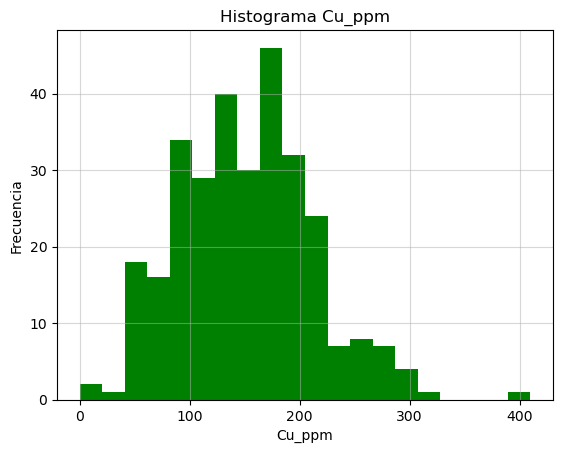

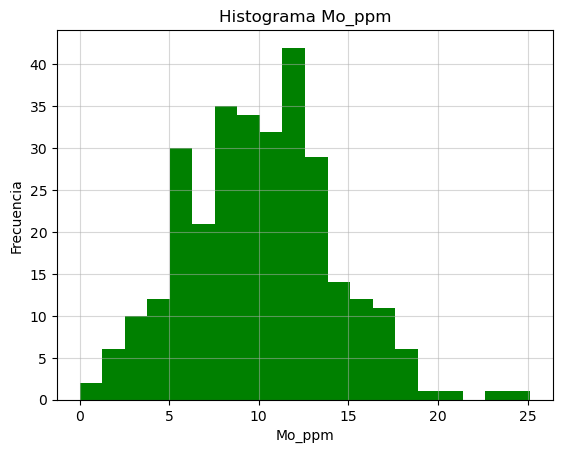

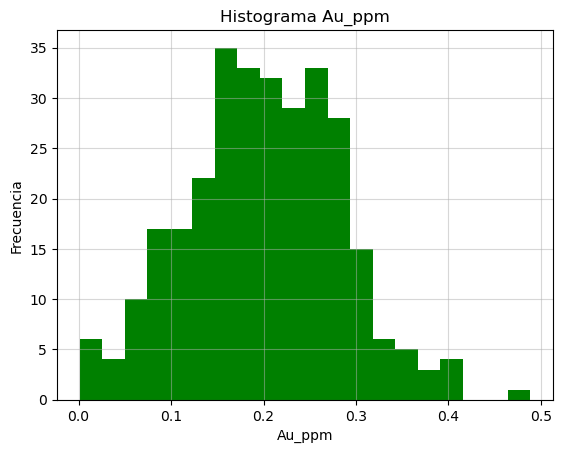

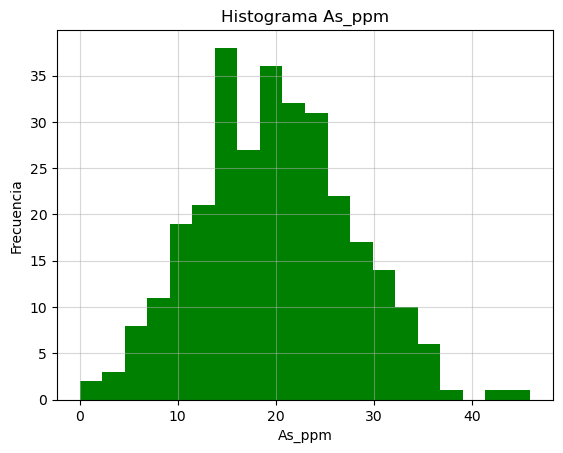

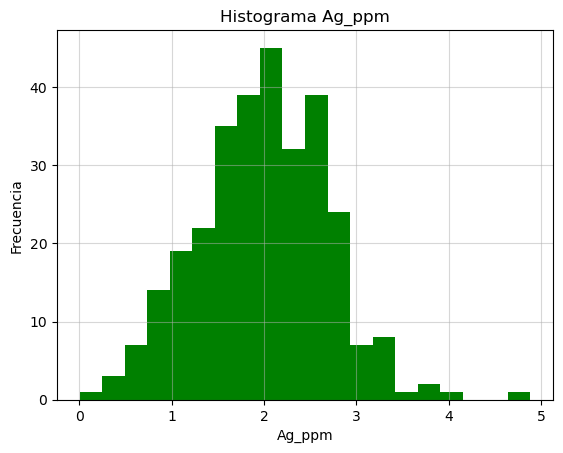

In [9]:
import matplotlib.pyplot as plt

principales = ["Cu_ppm","Mo_ppm","Au_ppm","As_ppm", "Ag_ppm"]

for el in principales:
    plt.hist(df[el], bins=20, color= "Green")
    plt.grid(alpha=0.5)
    plt.title(f"Histograma {el}")
    plt.xlabel(el)
    plt.ylabel("Frecuencia")
    plt.show()

Aplica:
log 10(𝑥+1)
Se suma 1 para evitar log(0).

La transformación log:
* Reduce asimetría
* Compacta valores extremos
* Aproxima distribución normal

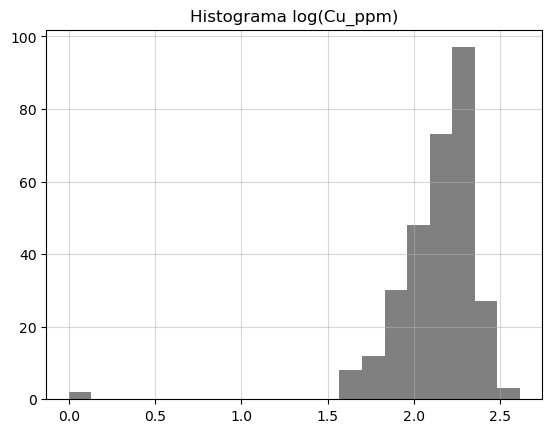

In [10]:
plt.hist(np.log10(df["Cu_ppm"]+1), bins=20, color="gray")
plt.grid(alpha=0.5)
plt.title("Histograma log(Cu_ppm)")
plt.show()

## Scatter plots

Este código genera un gráfico de dispersión donde cada punto representa una muestra del dataset, ubicando la concentración de cobre en el eje X y la de molibdeno en el eje Y, permitiendo visualizar visualmente si existe una tendencia o patrón de asociación entre ambos elementos.

Conceptos estadísticos

* Relación lineal
* Tendencia positiva o negativa
* Dispersión
* Asociación entre variables

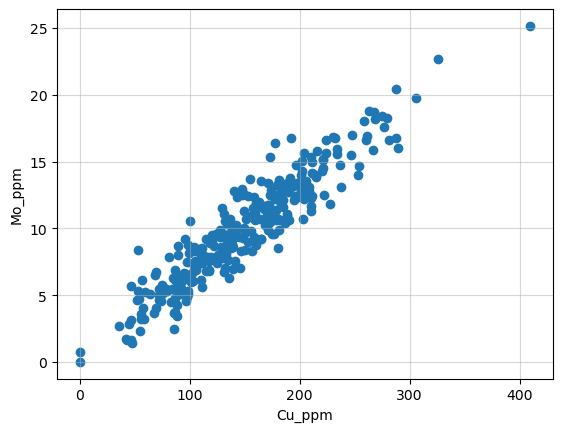

In [13]:
plt.scatter(df["Cu_ppm"], df["Mo_ppm"])
plt.xlabel("Cu_ppm")
plt.ylabel("Mo_ppm")
plt.grid (alpha=0.5)
plt.show()

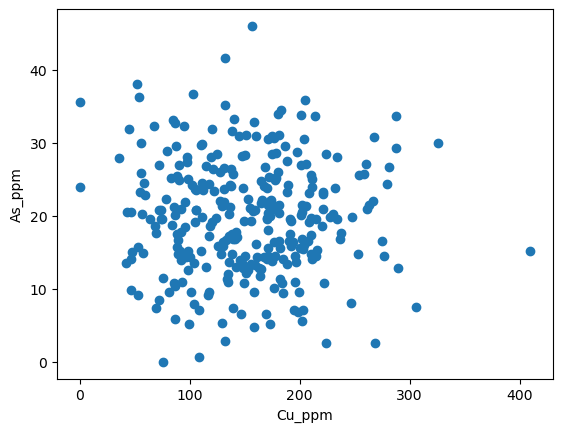

In [14]:
plt.scatter(df["Cu_ppm"], df["As_ppm"])
plt.xlabel("Cu_ppm")
plt.ylabel("As_ppm")
plt.show()

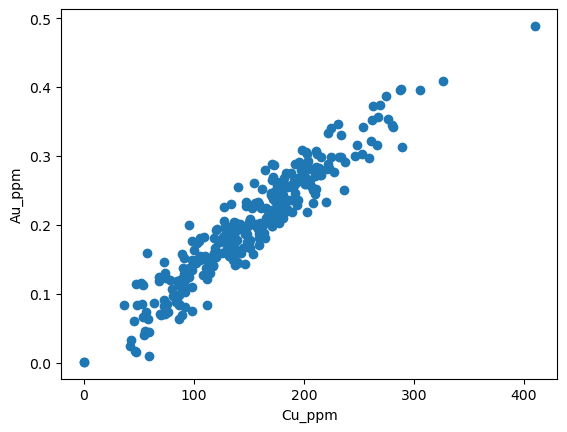

In [16]:
plt.scatter(df["Cu_ppm"], df["Au_ppm"])
plt.xlabel("Cu_ppm")
plt.ylabel("Au_ppm")
plt.show()

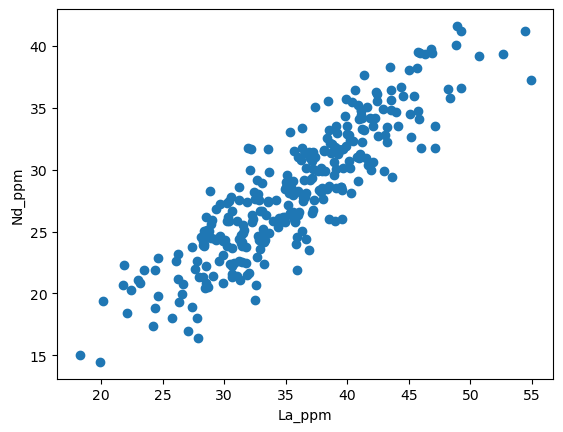

In [17]:
plt.scatter(df["La_ppm"], df["Nd_ppm"])
plt.xlabel("La_ppm")
plt.ylabel("Nd_ppm")
plt.show()

## Boxplot (sin normalizar)

Este código construye diagramas de caja para todos los elementos seleccionados utilizando sus valores originales, mostrando la mediana, la dispersión central y los valores extremos, permitiendo comparar la distribución de cada variable aunque todavía estén en distintas escalas.
Conceptos estadísticos

* Mediana
* Rango intercuartil (IQR)
* Valores atípicos (outliers)
* Dispersión
* Asimetría

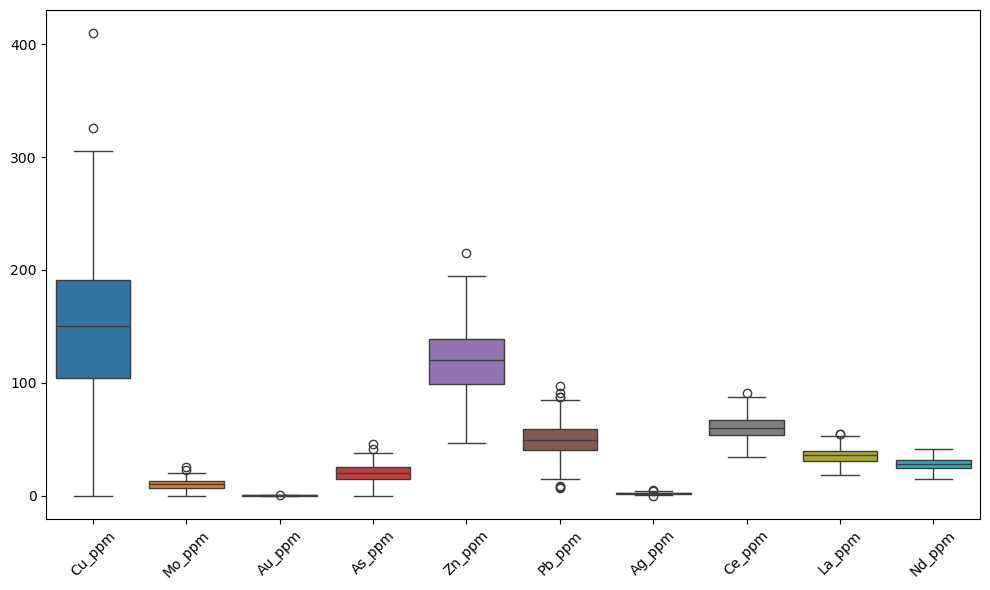

In [18]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(data=df[elementos])

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("figuras/boxplot_sin_normalizar.png", dpi=300)

plt.show()

## Normalizacion

Este bloque selecciona únicamente las columnas geoquímicas y aplica una transformación de estandarización a cada variable, restando su media y dividiendo por su desviación estándar, de modo que todas las variables queden expresadas en una misma escala relativa.


In [19]:
from sklearn.preprocessing import StandardScaler

# Seleccionar solo columnas numéricas
df_geoquimico = df[elementos].copy()

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_geoquimico)

df_scaled = pd.DataFrame(df_scaled, columns=elementos)

## Boxplots (estandarizados)

Este código genera nuevamente diagramas de caja, pero ahora utilizando las variables estandarizadas, lo que permite comparar directamente la variabilidad relativa de cada elemento sin que las diferencias de unidades o magnitudes distorsionen la visualización.

Conceptos estadísticos

* Comparación relativa
* Dispersión normalizada
* Valores extremos estandarizados
* Distribución centrada en cero

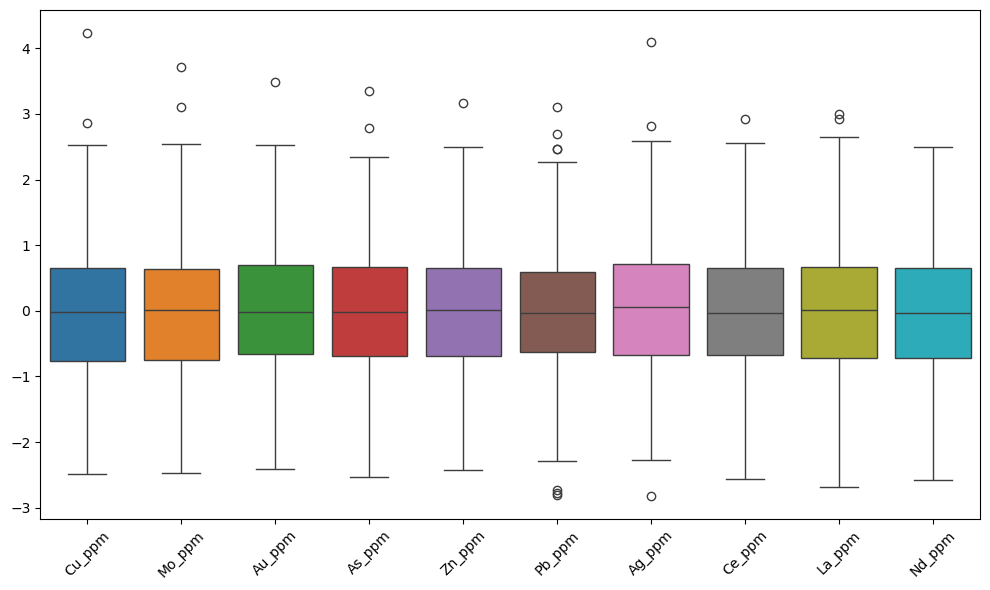

In [20]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(data=df_scaled)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("figuras/boxplot_normalizado.png", dpi=300)

plt.show()

## Boxplot Normalizado Interactivo (Z-Score)

Este código transforma el dataset a formato largo para que pueda ser interpretado por Plotly y genera un boxplot interactivo donde es posible inspeccionar valores individuales pasando el cursor sobre cada punto, facilitando la identificación de valores extremos y la comparación dinámica entre elementos.


In [21]:
from sklearn.preprocessing import StandardScaler

df_geoquimico = df[elementos].copy()

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_geoquimico),
    columns=df_geoquimico.columns
)

## Plotly

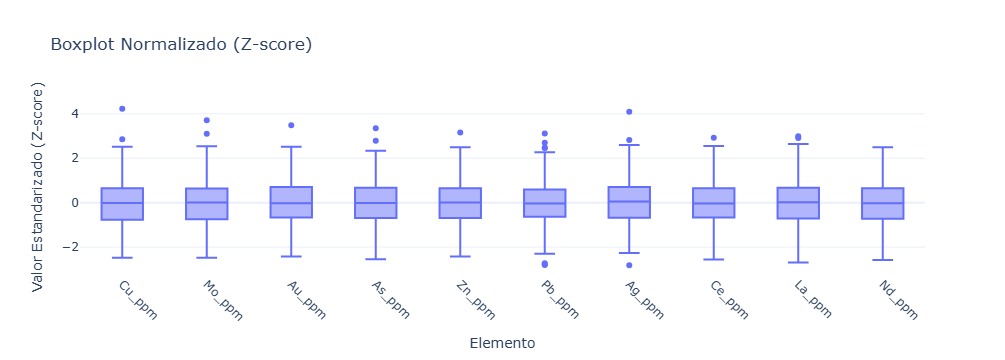

In [22]:
import plotly.express as px

# Convertir a formato largo (necesario para plotly)
df_long = df_scaled.melt(var_name="Elemento", value_name="Z_score")

fig = px.box(
    df_long,
    x="Elemento",
    y="Z_score",
    points="outliers",  # muestra outliers
    title="Boxplot Normalizado (Z-score)",
)

fig.update_layout(
    xaxis_title="Elemento",
    yaxis_title="Valor Estandarizado (Z-score)",
    xaxis_tickangle=45,
    template="plotly_white"
)

fig.show()

## Pairplot multivariado

Este bloque genera una matriz de gráficos donde en la diagonal se muestran histogramas individuales y fuera de la diagonal se presentan gráficos de dispersión entre todas las combinaciones posibles de los elementos seleccionados, permitiendo observar patrones multivariados de manera simultánea.

Conceptos estadísticos

* Distribución marginal
* Relación bivariada
* Asociación múltiple
* Posible agrupamiento natural

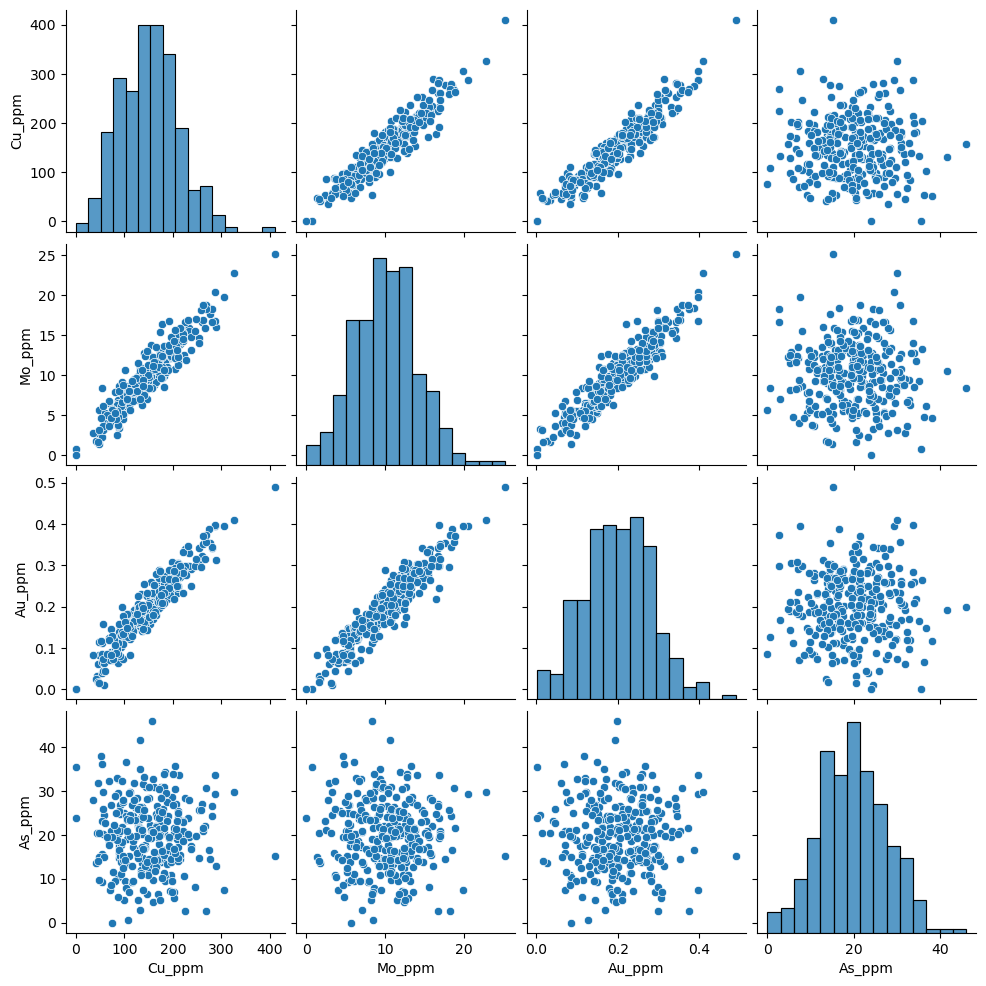

In [23]:
sns.pairplot(df[["Cu_ppm","Mo_ppm","Au_ppm","As_ppm"]])
plt.savefig("figuras/pairplot.png", dpi=300)
plt.show()

## Matriz de correlación 

Este código calcula el coeficiente de correlación lineal de Pearson entre todas las variables geoquímicas seleccionadas y lo representa mediante un mapa de calor, donde los colores y valores numéricos permiten identificar rápidamente el grado de asociación entre cada par de elementos.

Conceptos estadísticos

* Correlación de Pearson
* Asociación lineal
* Covarianza normalizada
* Rango de valores (-1 a 1)
* Independencia lineal

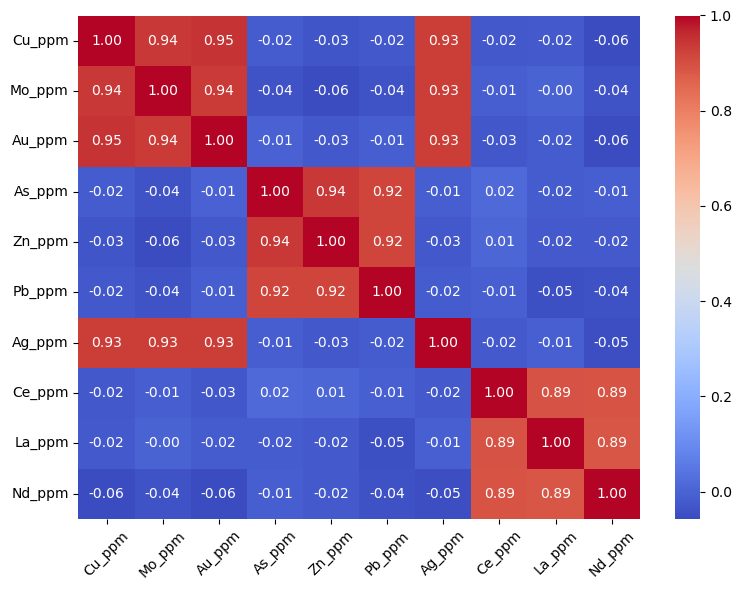

In [24]:
corr = df_geoquimico.corr(method="pearson")

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("figuras/heatmap.png", dpi=300, bbox_inches="tight")


plt.show()